In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import seaborn as sns


### 1. Завантаж за посиланням набір даних про успішність студентів, а також деяких особистісних, соціальних та економічних факторів, які можуть на неї впливати.

In [15]:
url_csv = 'https://docs.google.com/spreadsheets/d/1iDeLGl_udyK41wQwi2e1_J-qGd-9SL1eX7fdU30i908/gviz/tq?tvd=true&tqx=out:csv&gid=0'
data = pd.read_csv(url_csv)
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group D,some high school,standard,none,90,79,85
1,male,group A,some college,standard,none,60,55,52
2,female,group D,high school,standard,completed,91,100,95
3,female,group C,some college,free/reduced,completed,58,60,63
4,female,group D,some college,standard,none,64,68,73
...,...,...,...,...,...,...,...,...
995,male,group C,some high school,standard,none,55,54,50
996,male,group D,bachelor's degree,standard,completed,75,73,72
997,male,group C,high school,standard,completed,66,70,62
998,female,group D,bachelor's degree,standard,completed,75,84,93


### 2. Зобрази співвідношення балів за читання та письмо (стовпці reading score, writing score).

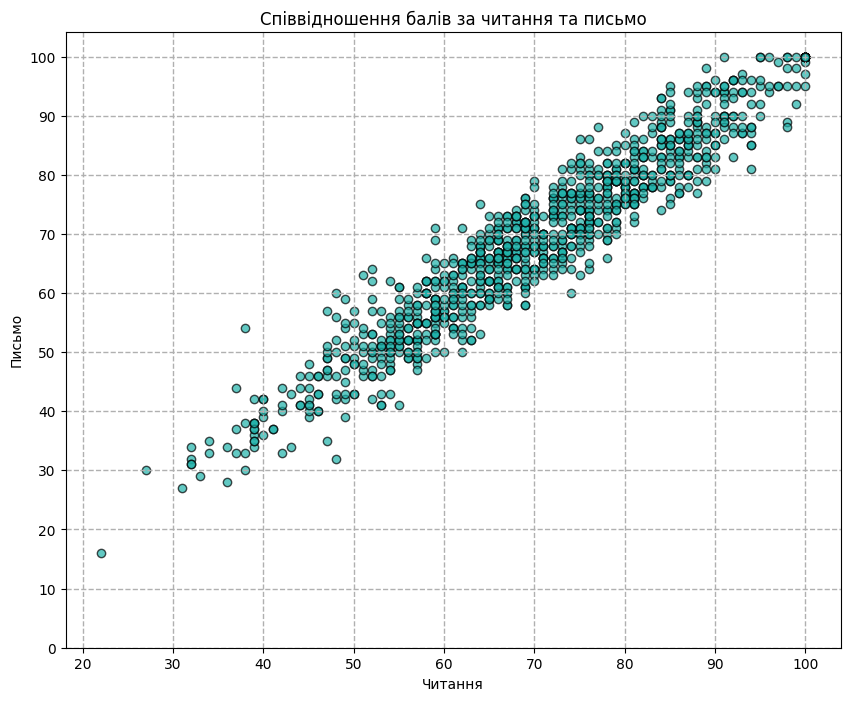

In [16]:
plt.figure(figsize=(10, 8))
plt.scatter(data['reading score'], data['writing score'], alpha=0.7, color='lightseagreen', edgecolor='black')
plt.yticks(range(0, 105, 10))
plt.title('Співвідношення балів за читання та письмо')
plt.xlabel('Читання')
plt.ylabel('Письмо')
plt.grid(True,linestyle='--', linewidth=1)
plt.show()


### 3. Додай на попередній графік третю ознаку: стать учня (gender).

/tmp/ipython-input-317054578.py:12: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(female_data['reading score'], female_data['writing score'],


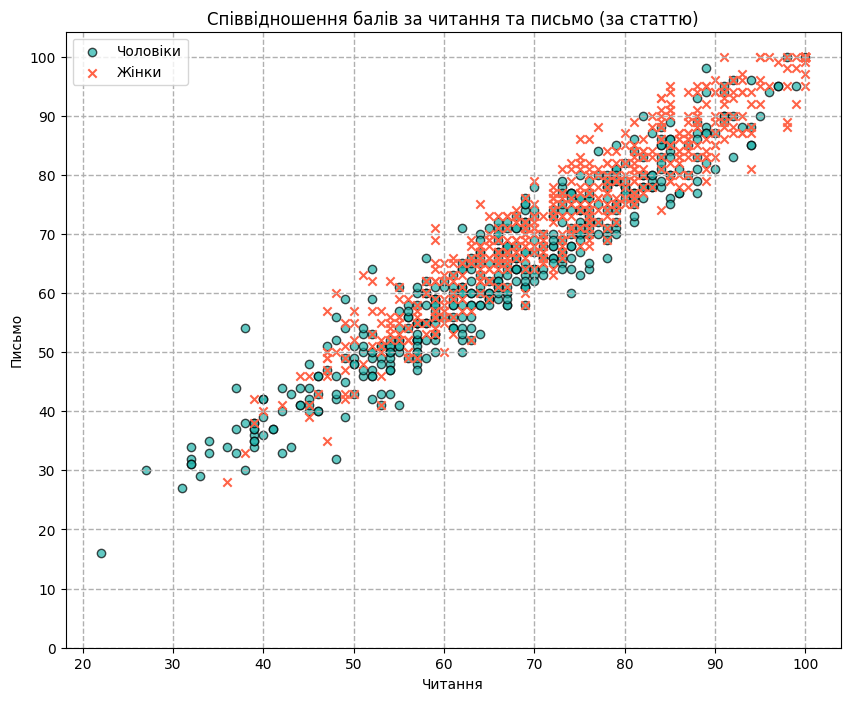

In [17]:
plt.figure(figsize=(10, 8))

# Preparing dfs for genders
male_data = data[data['gender'] == 'male']
female_data = data[data['gender'] == 'female']

# Males
plt.scatter(male_data['reading score'], male_data['writing score'],
            alpha=0.7, color='lightseagreen', edgecolor='black', label='Чоловіки')

# Females
plt.scatter(female_data['reading score'], female_data['writing score'],
            color='tomato', edgecolor='black', label='Жінки', marker='x')

plt.yticks(range(0, 105, 10))
plt.title('Співвідношення балів за читання та письмо (за статтю)')
plt.xlabel('Читання')
plt.ylabel('Письмо')
plt.legend()
plt.grid(True, linestyle='--', linewidth=1)
plt.show()

### 4. Візуалізуй розподіл ознаки етнічної приналежності (race/ethnicity).

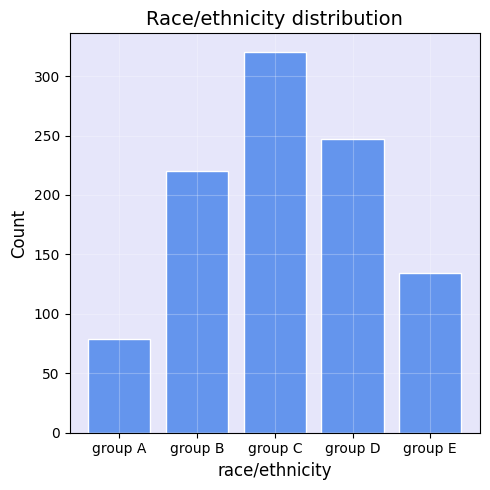

In [18]:
ethnical_distr = data.groupby('race/ethnicity')['math score'].count().reset_index().sort_values(by='race/ethnicity', ascending=True)

plt.figure(figsize=(5, 5))
ax = plt.gca()
ax.set_facecolor('lavender')
plt.bar(ethnical_distr['race/ethnicity'], ethnical_distr['math score'], color='cornflowerblue', edgecolor='white')
plt.title('Race/ethnicity distribution', fontsize=14)
plt.xlabel('race/ethnicity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, alpha=0.25, color='white')
plt.tight_layout()
plt.show()

### 5. Покажіть співвідношення оцінок за читання та письмо у різних етнічних групах.


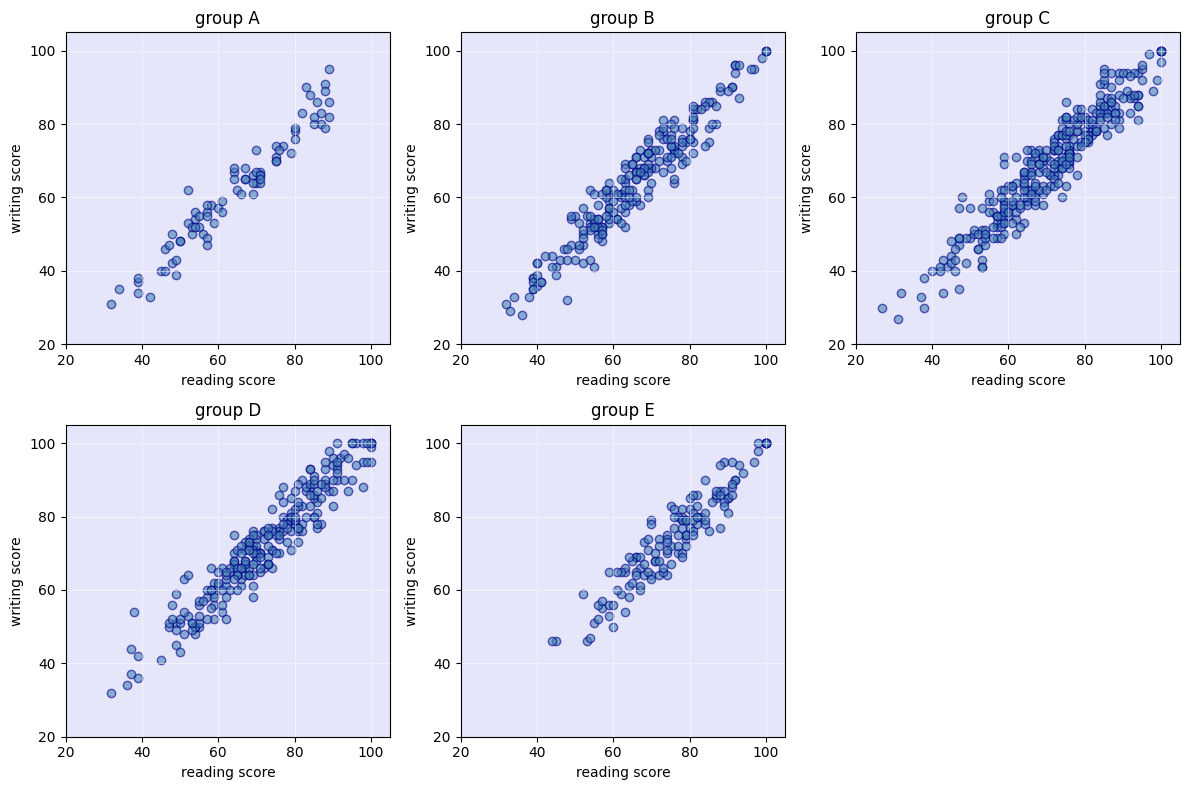

In [19]:
# Отримуємо унікальні етнічні групи
ethnic_groups = data['race/ethnicity'].unique()

# Створюємо сітку підграфіків (2 рядки, 3 стовпці)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))


# Розгортаємо axes в одновимірний список для зручності
axes = axes.flatten()

# Для кожної етнічної групи створюємо окремий графік
for i, group in enumerate(sorted(ethnic_groups)):
    group_data = data[data['race/ethnicity'] == group]

    axes[i].scatter(group_data['reading score'], group_data['writing score'],
                    alpha=0.6, color='steelblue', edgecolor='darkblue')
    axes[i].set_facecolor('lavender')
    axes[i].set_title(group, fontsize=12)
    axes[i].set_xlabel('reading score', fontsize=10)
    axes[i].set_ylabel('writing score', fontsize=10)
    axes[i].grid(True, alpha=0.5, color='white')
    axes[i].set_xlim(20, 105)
    axes[i].set_ylim(20, 105)
    axes[i].set_yticks(range(20, 101, 20))


# Якщо груп менше 6, приховуємо зайві підграфіки
for j in range(len(ethnic_groups), 6):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 6.Чи залежить в середньому оцінка з математики (math score) від проходження підготовчого курсу (test preparation course)? Додай на графік ще одну ознаку — стать учня. Чи є відмінності між хлопчиками та дівчатками по підготовці до тесту та результатам?

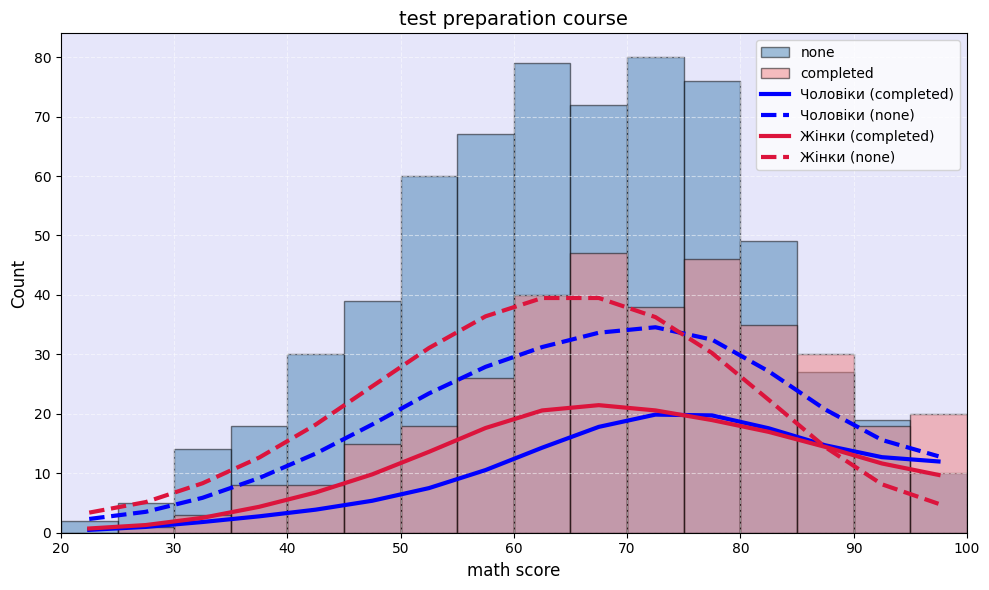

Середня оцінка з математики у чоловіків: 68.75
Середня оцінка з математики у жінок: 64.69


In [24]:
plt.figure(figsize=(10, 6))
plt.gca().set_facecolor('lavender')

# Filtering
none_data = data[data['test preparation course'] == 'none']['math score']
completed_data = data[data['test preparation course'] == 'completed']['math score']

# Cources completion
plt.hist(none_data, bins=range(0, 105, 5), alpha=0.5, label='none',
         color='steelblue', edgecolor='black')
plt.hist(completed_data, bins=range(0, 105, 5), alpha=0.5, label='completed',
         color='lightcoral', edgecolor='black')
bins = range(20, 105, 5)
male_none = data[(data['test preparation course'] == 'none') & (data['gender'] == 'male')]['math score']
male_completed = data[(data['test preparation course'] == 'completed') & (data['gender'] == 'male')]['math score']
female_none = data[(data['test preparation course'] == 'none') & (data['gender'] == 'female')]['math score']
female_completed = data[(data['test preparation course'] == 'completed') & (data['gender'] == 'female')]['math score']


# Створюємо гістограми для кожної групи
hist_male_none, bin_edges = np.histogram(male_none, bins=bins)
hist_male_completed, _ = np.histogram(male_completed, bins=bins)
hist_female_none, _ = np.histogram(female_none, bins=bins)
hist_female_completed, _ = np.histogram(female_completed, bins=bins)

# Центри інтервалів
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Згладжуємо лінії
hist_male_none_smooth = gaussian_filter1d(hist_male_none.astype(float), sigma=1.5)
hist_male_completed_smooth = gaussian_filter1d(hist_male_completed.astype(float), sigma=1.5)
hist_female_none_smooth = gaussian_filter1d(hist_female_none.astype(float), sigma=1.5)
hist_female_completed_smooth = gaussian_filter1d(hist_female_completed.astype(float), sigma=1.5)

# Малюємо лінії
# Чоловіки: суцільна лінія (completed), пунктирна (none)
plt.plot(bin_centers, hist_male_completed_smooth, color='blue', linewidth=3,
         linestyle='-', label='Чоловіки (completed)')
plt.plot(bin_centers, hist_male_none_smooth, color='blue', linewidth=3,
         linestyle='--', label='Чоловіки (none)')

# Жінки: суцільна лінія (completed), пунктирна (none)
plt.plot(bin_centers, hist_female_completed_smooth, color='crimson', linewidth=3,
         linestyle='-', label='Жінки (completed)')
plt.plot(bin_centers, hist_female_none_smooth, color='crimson', linewidth=3,
         linestyle='--', label='Жінки (none)')


plt.xlabel('math score', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('test preparation course', fontsize=14)
plt.legend()
plt.xlim(20, 100)
plt.grid(True, linestyle='--', alpha=0.5,color='white')
plt.tight_layout()
plt.show()

#Statistics
print(f"Середня оцінка з математики у чоловіків: {round(male_data['math score'].mean(),2)}")
print(f"Середня оцінка з математики у жінок: {round(female_data['math score'].mean(),2)}")

Висновок: так, оцінка з математики залежить від того, чи проходив студент підготовчий курс. Це видно не оцінках, як > 85 балів. Ті, хто пройшли підготовчий курс, з більшою вірогідністю здадуть екзамен на 80+ балів. Щодо залежності статі/оцінки/курса, то можна побачити, що більшість студентів не проходила підготовчий курс і, не дивлячись на це, всі змогли здати іспит на середній бал. Також, можна побачити, що до порогу в 70 балів, жінки здають екзамен краще, ніж чоловіки, а починаючи з 70 навпаки. Якщо повернутись на пару візуалізацій назад, то можна побачити, що в діапазоні 80-100 балів за письмо більше жінок. Як загальний висновок щодо наданих студентів у вибірці, жінки кращі в іспиті з письма, а чоловіки з математики.

### 7. Який з факторів — етнічна приналежність або рівень освіти батьків (parental level of education) — більше взаємопов’язаний з оцінкою із математики?

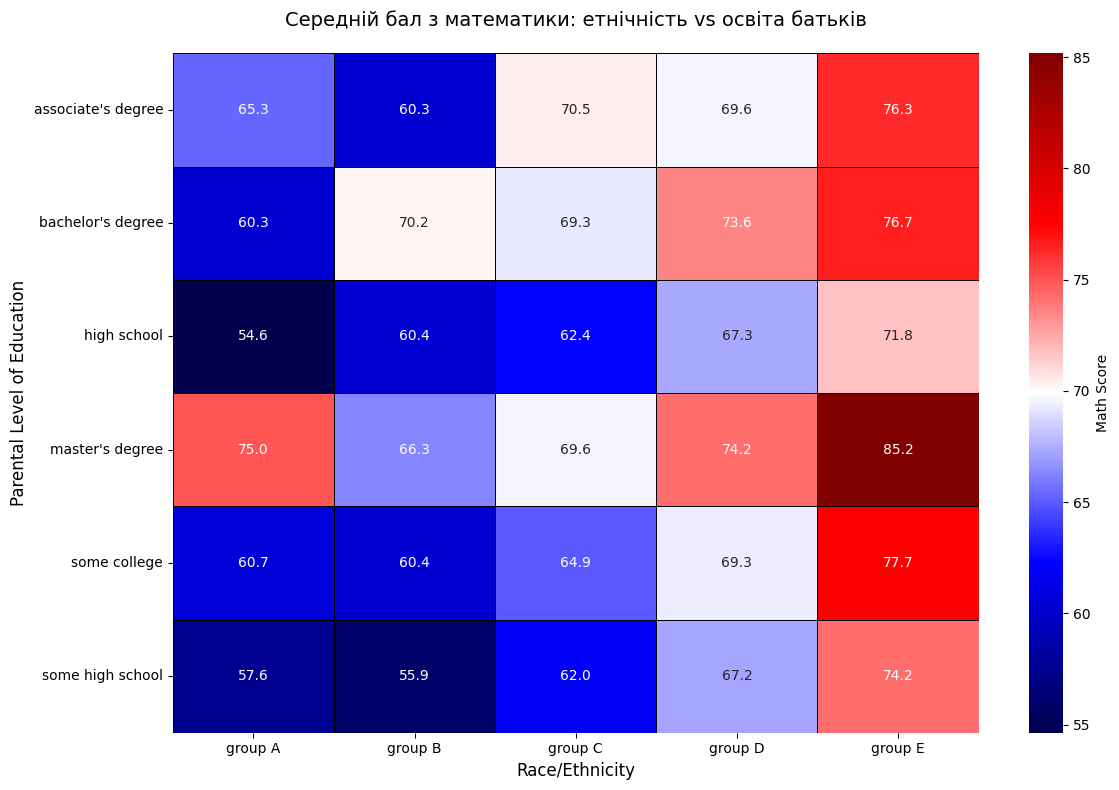

In [26]:
# First of all we need to count average per race and parent's educational level
heatmap_data = data.groupby(['race/ethnicity', 'parental level of education'])['math score'].mean().reset_index()

pivot_table = heatmap_data.pivot(index='parental level of education',
                                   columns='race/ethnicity',
                                   values='math score')


plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='seismic',
            linewidths=0.5, linecolor='black', cbar_kws={'label': 'Math Score'})

plt.title('Середній бал з математики: етнічність vs освіта батьків', fontsize=14, pad=20)
plt.xlabel('Race/Ethnicity', fontsize=12)
plt.ylabel('Parental Level of Education', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Я вирішила, що для пошуку такої залежності краще використати heatmap, адже вона чудово показує кореляцію певних факторів між собою. На графіку вище можна легко побачити, що так, оцінки студентів залежать від етнічної приналежності та освіти батьків.
Більше всього впливає саме race/ethnicity, адже у студентів з групи Е середній бал з математики найбільший серед інших груп. Також чудово видно, що у студентів, чиї батьки мають магістерську освіту, середні бали вище майже по всім етнічним групам.
Також ми бачимо максимум та мінімум по вибірці:
- Найгірший бал в Group A з освітою high school - 54.6
- Найкращий бал в Group Е з освітою master's degree - 85.2